# Distancia de seguridad / GAP

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength
c=3*10^8 # m/s


In [2]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

$k=\sin^2(1/2*(L/L_{pi}))    $   

Despejando la longitud L_pi:

$\sqrt(k)=\sin(1/2*(L/L_{pi}))  $                                                                            
$\arcsin(\sqrt(k))=1/2*(L/L_{pi})$
$2*\arcsin(\sqrt(k))=(L/{L_pi})  $                   
${L_pi}=(L/2*\arcsin(\sqrt(k))) $       

Para que sea seguro k=0.01, entonces:
                                                                                                                                      

In [37]:
k=0.1
L=10e3
L_pi2=(L/(2*np.arcsin(np.sqrt(k))))
print(f"L_pi debe ser de {np.round(L_pi2,3)} um para tener un acople menor a {k}")


L_pi debe ser de 15539.989 um para tener un acople menor a 0.1


Vamos a variar el gap para así ver como afecta el gap el L_pi, adicionalmente los DC tendrán un ancho de las guias de onda de 450 nm

In [44]:

gap_to_simulate = (1/100)*np.linspace(96, 100, 5) 
#gap_to_simulate = (1/10)*np.linspace(10, 14, 9)                            
wavelength=1.55
L_pi_TE=[]
L_pi_TM=[]

for i in range(0,len(gap_to_simulate),1):
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(450*nm, 450*nm), # Waveguide width
        gap=gap_to_simulate[i],
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=220 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.6, # Parameters of the grid
        grid_resolution=40 # Parameters of the grid
    )

    dcoupler_neff = deep_dcoupler_cs.n_eff
    #print("------Fraction of TE-----")
    #print(deep_dcoupler_cs.fraction_te)
    # TE Modes: Modes 0 & 1
    L_pi_TE.append( 0.5*wavelength/(dcoupler_neff[0].real-dcoupler_neff[1].real))



/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 12:19:28.840 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e27d70f84a6cf7fa.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 12:19:44.557 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e1845d44253af4ee.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 12:19:58.185 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_3f130f17263eacba.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 12:20:10.804 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_9310ea2e8f3eaa02.npz.
2026-04-13 12:20:10.853 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b88b012409ae6b2e.npz.


/tmp/ipykernel_23555/2781408355.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(gap_to_simulate, L_pi2*np.ones(len(gap_to_simulate)),'k--', label='L_pi buscada', color='r')


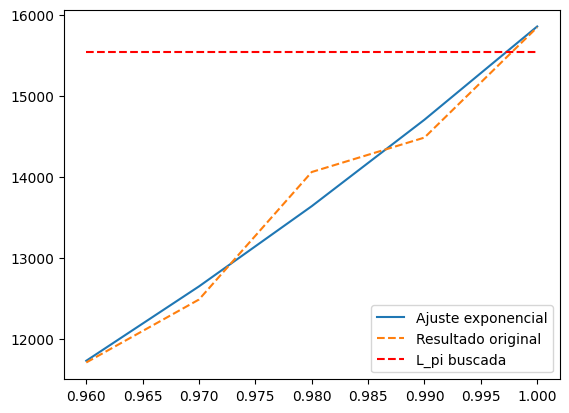

In [45]:

log_L_pi = np.log(L_pi_TE)
# ajuste lineal
BL, logAL = np.polyfit(gap_to_simulate, log_L_pi, 1)

AL = np.exp(logAL)

L_pi_fit_Log = AL * np.exp(BL * gap_to_simulate)

# verifico en la gráficaa que se encuentre el valor de 49916.42933419951 um de L_pi

plt.plot(gap_to_simulate, L_pi_fit_Log, label="Ajuste exponencial")
plt.plot(gap_to_simulate, L_pi_TE, label="Resultado original", linestyle="--")
plt.plot(gap_to_simulate, L_pi2*np.ones(len(gap_to_simulate)),'k--', label='L_pi buscada', color='r')

plt.legend()
plt.show()

In [50]:
wg_gap_3=np.log(L_pi2/AL)/BL 
print(f"Así, la distancia entre una y otra guia de onda, debe ser de {np.round(wg_gap_3,3)} um")

Así, la distancia entre una y otra guia de onda, debe ser de 0.997 um


Redondeamos, porque hallar distancias muy exactas de 0.997 puede ser complejo. 

In [51]:
deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(450*nm, 450*nm), # Waveguide width
        gap=np.round(wg_gap_3,0),
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=220 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.6, # Parameters of the grid
        grid_resolution=40 # Parameters of the grid
    )

dcoupler_neff = deep_dcoupler_cs.n_eff
#print("------Fraction of TE-----")
#print(deep_dcoupler_cs.fraction_te)
# TE Modes: Modes 0 & 1
L_pi_TE_veri= 0.5*wavelength/(dcoupler_neff[0].real-dcoupler_neff[1].real)
k=(np.sin(1/2*(L/L_pi_TE_veri)))**2   

print(f"Verificamos que con una distancia de {np.round(wg_gap_3,0)} um, nos da un acople de {np.round(k,4)} \n")

2026-04-13 12:22:56.949 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b88b012409ae6b2e.npz.
Verificamos que con una distancia de 1.0 um, nos da un acople de 0.0963 



Luego, la distancia minima de separación entre una guia de onda y la otra, debe ser de 1 um.